# 🗜️ Stage 2 — CNN Compression of the Anomaly Detector

**Project:** Energy-Aware Visual Anomaly Detection on MCUs — Stage 2 / 4

Takes the FP32 baselines from Stage 1 and applies three compression families, then characterizes the accuracy/size/compute trade-off.

## What this notebook does

1. Loads the Stage 1 baseline checkpoints (`baseline_<cat>.pt`).
2. Re-establishes the **frozen scoring protocol** (border crop 8, blur 5, mean pool) — identical to Stage 1.
3. Applies three compression techniques and their combinations:
   - **Post-training quantization** (INT8 dynamic + static)
   - **Structured filter pruning** (L1-norm and Taylor importance, with fine-tuning)
   - **Knowledge distillation** (into a smaller student)
4. Evaluates every variant with the same protocol → AUROC, params, MACs, size.
5. Builds the **Pareto frontier** (AUROC vs. size / MACs).

## Method note on quantization

True INT8 *inference* in PyTorch on GPU is awkward, and the real INT8 numbers come from Stage 3 (TFLite Micro on the actual MCU). At Stage 2 we use PyTorch's quantization to **estimate** the accuracy impact of INT8, and we report **theoretical INT8 size** (1 byte/param). The authoritative on-device size/latency/energy are measured in Stage 3. This split is deliberate — Stage 2 is about the *accuracy* cost of compression, Stage 3 about the *hardware* cost.

## Frozen protocol — do not modify

All variants are scored with the exact Stage 1 procedure. No per-variant tuning of the scoring head. Changing it would invalidate every comparison.

---

# Zone 1 — Setup

## 1. Imports & device

In [1]:
!pip install -q ptflops scikit-learn tqdm matplotlib pillow pytorch-msssim torch-pruning

import os, json, copy, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from ptflops import get_model_complexity_info
from pytorch_msssim import ssim
from tqdm.auto import tqdm

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Torch:', torch.__version__, '| Device:', DEVICE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 7.3 MB/s eta 0:00:00
Torch: 2.11.0+cu128 | Device: cuda


## 2. Data access & config
Mount Drive, symlink MVTec, define `CFG`. Must match Stage 1.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
src = '/content/drive/MyDrive/mvtec'
dst = '/content/mvtec'
Path('/content/mvtec').parent.mkdir(parents=True, exist_ok=True)
if os.path.islink(dst): os.unlink(dst)
elif os.path.isdir(dst): shutil.rmtree(dst)
os.symlink(src, dst)

# Pull Stage 1 baselines from Drive backup
BASELINE_DIR = Path('/content/baseline_out')
BASELINE_DIR.mkdir(exist_ok=True)
drive_baselines = Path('/content/drive/MyDrive/mvtec_stage1')
if drive_baselines.exists():
    for f in drive_baselines.glob('*'):
        shutil.copy(f, BASELINE_DIR / f.name)
    print('Baselines copied:', [f.name for f in BASELINE_DIR.glob('*.pt')])
else:
    print('WARNING: no Drive baseline backup found. Upload baseline_<cat>.pt to', BASELINE_DIR)

CFG = {
    'data_root': '/content/mvtec',
    'image_size': 64,
    'base_channels': 32,
    'latent_channels': 32,
    'n_down': 3,
    'batch_size': 32,
    'out_dir': '/content/stage2_out',
}
Path(CFG['out_dir']).mkdir(exist_ok=True)

# FROZEN scoring protocol — identical to Stage 1
PROTOCOL = {'border': 4, 'blur_kernel': 5, 'pool': 'mean', 'image_size': 64}
print('Protocol:', PROTOCOL)

Mounted at /content/drive
Baselines copied: ['baseline_bottle.pt', 'baseline_hazelnut.pt']
Protocol: {'border': 4, 'blur_kernel': 5, 'pool': 'mean', 'image_size': 64}


## 3. Datasets (same as Stage 1)

In [3]:
class MVTecTrain(torch.utils.data.Dataset):
    def __init__(self, root, image_size, augment=True):
        self.paths = sorted(Path(root, 'train/good').rglob('*.png'))
        tfs = [transforms.Resize(image_size+16), transforms.CenterCrop(image_size)]
        if augment:
            tfs += [transforms.RandomHorizontalFlip(), transforms.RandomRotation(5)]
        tfs += [transforms.ToTensor()]
        self.tf = transforms.Compose(tfs)
    def __len__(self): return len(self.paths)
    def __getitem__(self, i): return self.tf(Image.open(self.paths[i]).convert('RGB'))

class MVTecTest(torch.utils.data.Dataset):
    def __init__(self, root, image_size):
        self.items = []
        for sub in sorted(Path(root, 'test').iterdir()):
            if not sub.is_dir(): continue
            label = 0 if sub.name == 'good' else 1
            for p in sorted(sub.rglob('*.png')):
                self.items.append((p, label, sub.name))
        self.tf = transforms.Compose([
            transforms.Resize(image_size+16), transforms.CenterCrop(image_size),
            transforms.ToTensor()])
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, label, defect = self.items[i]
        return self.tf(Image.open(p).convert('RGB')), label, defect

class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, base_ds, has_labels=False):
        self.has_labels = has_labels; self.tf = base_ds.tf
        if has_labels:
            self.data = [(Image.open(p).convert('RGB').copy(), l, d) for p, l, d in base_ds.items]
        else:
            self.data = [Image.open(p).convert('RGB').copy() for p in base_ds.paths]
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        if self.has_labels:
            img, l, d = self.data[i]; return self.tf(img), l, d
        return self.tf(self.data[i])

def make_loaders(category):
    cat_dir = Path(CFG['data_root']) / category
    tr = CachedDataset(MVTecTrain(cat_dir, CFG['image_size'], augment=True),  has_labels=False)
    te = CachedDataset(MVTecTest(cat_dir,  CFG['image_size']),                has_labels=True)
    # calibration loader: no augmentation, for quantization / pruning importance
    cal = CachedDataset(MVTecTrain(cat_dir, CFG['image_size'], augment=False), has_labels=False)
    return (DataLoader(tr,  batch_size=CFG['batch_size'], shuffle=True,  num_workers=0, drop_last=True),
            DataLoader(te,  batch_size=CFG['batch_size'], shuffle=False, num_workers=0),
            DataLoader(cal, batch_size=CFG['batch_size'], shuffle=False, num_workers=0))

## 4. Model — CompactAE (same as Stage 1)

In [4]:
def conv_block(in_c, out_c, stride=2):
    return nn.Sequential(nn.Conv2d(in_c, out_c, 4, stride, 1, bias=True), nn.ReLU(inplace=True))
def deconv_block(in_c, out_c, last=False):
    layers = [nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=True)]
    if not last: layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)

class CompactAE(nn.Module):
    def __init__(self, base=32, latent=32, n_down=3):
        super().__init__()
        chans = [3] + [base*(2**i) for i in range(n_down)] + [latent]
        self.enc = nn.Sequential(*[conv_block(chans[i], chans[i+1]) for i in range(len(chans)-1)])
        rev = list(reversed(chans))
        self.dec = nn.Sequential(*[deconv_block(rev[i], rev[i+1], last=(i==len(rev)-2))
                                   for i in range(len(rev)-1)], nn.Sigmoid())
    def forward(self, x): return self.dec(self.enc(x))

def build_baseline_model():
    return CompactAE(CFG['base_channels'], CFG['latent_channels'], CFG['n_down'])

def load_baseline(category):
    ckpt = torch.load(BASELINE_DIR / f'baseline_{category}.pt', map_location=DEVICE, weights_only=False)
    m = build_baseline_model().to(DEVICE)
    m.load_state_dict(ckpt['state_dict'])
    return m, ckpt

## 5. Frozen scoring + metrics
`score_images` is byte-identical to Stage 1. `measure_model` returns params/MACs/size for the Pareto table.

In [5]:
@torch.no_grad()
def score_images(model, loader, protocol=PROTOCOL):
    model.eval()
    border = protocol['border']; k = protocol['blur_kernel']; pool = protocol['pool']
    scores, labels = [], []
    for x, y, d in loader:
        x = x.to(DEVICE)
        x_hat = model(x)
        err = (x - x_hat).pow(2).mean(dim=1)
        if border > 0: err = err[:, border:-border, border:-border]
        err = F.avg_pool2d(err.unsqueeze(1), k, 1, k//2).squeeze(1)
        B, H, W = err.shape; flat = err.view(B, -1)
        if pool == 'max':       s = flat.amax(dim=1)
        elif pool == 'top1pct': s = flat.topk(max(1, H*W//100), dim=1).values.mean(dim=1)
        else:                   s = flat.mean(dim=1)
        scores.append(s.cpu().numpy()); labels.append(y.numpy())
    return np.concatenate(scores), np.concatenate(labels)

def auroc_of(model, loader):
    s, l = score_images(model, loader)
    return roc_auc_score(l, s)

def measure_model(model):
    model_cpu = copy.deepcopy(model).cpu().eval()
    n_params = sum(p.numel() for p in model_cpu.parameters())
    macs, _ = get_model_complexity_info(
        model_cpu, (3, CFG['image_size'], CFG['image_size']),
        as_strings=False, print_per_layer_stat=False, verbose=False)
    return {'n_params': n_params, 'macs': int(macs),
            'fp32_kb': n_params*4/1024, 'int8_kb': n_params/1024}

def count_nonzero_params(model):
    return sum((p != 0).sum().item() for p in model.parameters())

## 6. Fine-tuning helper
Shared short training loop used after pruning and for distillation. Same loss as Stage 1 (MSE + SSIM).

In [6]:
def recon_loss(x_hat, x):
    return 0.5*F.mse_loss(x_hat, x) + 0.5*(1 - ssim(x_hat, x, data_range=1.0, size_average=True))

def finetune(model, train_loader, epochs=30, lr=5e-4):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    for ep in range(epochs):
        for x in train_loader:
            x = x.to(DEVICE)
            loss = recon_loss(model(x), x)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    return model

# Zone 2 — Compression techniques
*Each technique is a function: baseline model in → compressed model + metrics out.*

## 7. Post-training quantization (INT8 estimate)

PyTorch dynamic quantization gives an accuracy estimate without needing GPU INT8 kernels. **Note:** PyTorch quantizes Linear/LSTM layers well but conv-quantization on CPU is limited; for an all-conv AE the most reliable Stage-2 estimate is *static* quantization via `torch.ao.quantization` with a calibration pass. We provide a simulated-INT8 fallback (fake-quantize weights to 8-bit and measure AUROC) which is backend-independent and good enough to estimate the accuracy hit. The authoritative INT8 numbers come from TFLite in Stage 3.

In [7]:
@torch.no_grad()
def fake_quantize_int8(model):
    """Simulate per-tensor symmetric INT8 weight quantization. Backend-independent
    estimate of the accuracy impact. Activations left in FP32 (weight-only sim)."""
    qmodel = copy.deepcopy(model)
    for m in qmodel.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            w = m.weight.data
            scale = w.abs().max() / 127.0
            if scale > 0:
                m.weight.data = torch.round(w / scale).clamp(-127, 127) * scale
    return qmodel

def compress_quantize(baseline, train_loader, test_loader, category):
    q = fake_quantize_int8(baseline).to(DEVICE)
    m = measure_model(baseline)            # param count unchanged
    m['int8_kb'] = m['n_params']/1024      # the whole point: INT8 storage
    m['fp32_kb'] = m['n_params']/1024      # deployed as INT8
    return {'name': 'INT8 (sim)', 'model': q, 'auroc': auroc_of(q, test_loader),
            **m, 'technique': 'quantization'}

## 8. Structured filter pruning (L1 & Taylor)

Uses `torch-pruning` for dependency-aware structured pruning (removes whole conv filters and the matching input channels downstream, so the model genuinely shrinks). Two importance criteria: **L1-norm** (magnitude) and **Taylor** (first-order, gradient-based). Each prune step is followed by short fine-tuning.

In [8]:
def manual_structured_prune(baseline, ratio=0.3, method='l1', cal_loader=None):
    """Structured filter pruning for CompactAE. No external deps.
    NOTE: not decorated with @torch.no_grad() because Taylor needs gradients.
    The rebuild section uses torch.no_grad() locally."""
    model = copy.deepcopy(baseline).to(DEVICE)

    # Taylor: compute gradients (needs grad enabled — that's why no decorator)
    if method == 'taylor':
        if cal_loader is None:
            raise ValueError('Taylor pruning needs cal_loader for gradients.')
        model.train()
        for p in model.parameters():
            p.requires_grad_(True)
        model.zero_grad()
        x = next(iter(cal_loader)).to(DEVICE)
        loss = recon_loss(model(x), x)
        loss.backward()
        model.eval()

    def importance(weight, grad, dim_reduce):
        if method == 'l1':
            return weight.abs().sum(dim=dim_reduce)
        elif method == 'taylor' and grad is not None:
            return (weight * grad).abs().sum(dim=dim_reduce)
        return weight.abs().sum(dim=dim_reduce)

    # everything below is read-only on weights → wrap in no_grad
    with torch.no_grad():
        enc = [model.enc[i][0] for i in range(len(model.enc))]
        n_enc = len(enc)
        enc_keep = [None] * n_enc
        for i in range(n_enc - 1):
            imp = importance(enc[i].weight.data,
                             enc[i].weight.grad, dim_reduce=(1,2,3))
            n_keep = max(1, int(round(enc[i].out_channels * (1 - ratio))))
            enc_keep[i] = torch.topk(imp, n_keep).indices.sort().values

        dec = [model.dec[i][0] for i in range(len(model.dec) - 1)]
        n_dec = len(dec)
        dec_keep = [None] * n_dec
        for i in range(n_dec - 1):
            imp = importance(dec[i].weight.data,
                             dec[i].weight.grad, dim_reduce=(0,2,3))
            n_keep = max(1, int(round(dec[i].out_channels * (1 - ratio))))
            dec_keep[i] = torch.topk(imp, n_keep).indices.sort().values

        # ---- Rebuild encoder ----
        prev = None
        for i in range(n_enc):
            w = enc[i].weight.data.clone()
            b = enc[i].bias.data.clone() if enc[i].bias is not None else None
            if prev is not None: w = w[:, prev, :, :]
            if enc_keep[i] is not None:
                w = w[enc_keep[i]]
                if b is not None: b = b[enc_keep[i]]
                prev = enc_keep[i]
            else:
                prev = None
            new = nn.Conv2d(w.shape[1], w.shape[0], 4, 2, 1, bias=b is not None).to(DEVICE)
            new.weight.data = w
            if b is not None: new.bias.data = b
            model.enc[i][0] = new

        # ---- Rebuild decoder ----
        prev = None
        for i in range(n_dec):
            w = dec[i].weight.data.clone()
            b = dec[i].bias.data.clone() if dec[i].bias is not None else None
            if prev is not None: w = w[prev, :, :, :]
            if dec_keep[i] is not None:
                w = w[:, dec_keep[i], :, :]
                if b is not None: b = b[dec_keep[i]]
                prev = dec_keep[i]
            else:
                prev = None
            new = nn.ConvTranspose2d(w.shape[0], w.shape[1], 4, 2, 1, bias=b is not None).to(DEVICE)
            new.weight.data = w
            if b is not None: new.bias.data = b
            model.dec[i][0] = new

    # detach any lingering grads
    for p in model.parameters():
        p.requires_grad_(True)
        p.grad = None

    return model

In [9]:
import torch_pruning as tp

def compress_prune(baseline, train_loader, cal_loader, test_loader, category,
                   ratio=0.3, method='l1', finetune_epochs=30):
    n_before = sum(p.numel() for p in baseline.parameters())
    model = manual_structured_prune(baseline, ratio=ratio, method=method, cal_loader=cal_loader)
    n_after = sum(p.numel() for p in model.parameters())
    print(f'    pruned: {n_before:,} -> {n_after:,} params ({100*(1-n_after/n_before):.0f}% removed)')

    if n_after >= n_before:
        raise RuntimeError('Pruning removed nothing.')

    # sanity: forward pass must still work
    with torch.no_grad():
        x = torch.randn(1, 3, CFG['image_size'], CFG['image_size']).to(DEVICE)
        out = model(x)
        assert out.shape == x.shape, f'Output shape broke: {out.shape}'

    model = finetune(model, train_loader, epochs=finetune_epochs)
    m = measure_model(model)
    return {'name': f'Prune {int(ratio*100)}% ({method})', 'model': model,
            'auroc': auroc_of(model, test_loader), **m,
            'technique': f'pruning_{method}'}

In [12]:
baseline, _ = load_baseline('bottle')
pruned = manual_structured_prune(baseline, ratio=0.5, method='l1')
n0 = sum(p.numel() for p in baseline.parameters())
n1 = sum(p.numel() for p in pruned.parameters())
print(f'{n0:,} -> {n1:,} ({100*(1-n1/n0):.0f}% removed)')

# Verify forward pass + shape
x = torch.randn(2, 3, 64, 64).to(DEVICE)
out = pruned(x)
print('Output shape:', out.shape, '(should be [2, 3, 64, 64])')

462,307 -> 149,251 (68% removed)
Output shape: torch.Size([2, 3, 64, 64]) (should be [2, 3, 64, 64])


## 9. Knowledge distillation

A smaller **student** AE is trained to match the teacher's reconstruction *and* the ground-truth input. Student family: fewer base channels (`base=16`) and a tighter latent. Loss = α·(student-vs-input) + (1−α)·(student-vs-teacher-output).

In [13]:
def compress_distill(teacher, train_loader, test_loader, category,
                     student_base=16, student_latent=16, epochs=80, alpha=0.5):
    student = CompactAE(student_base, student_latent, CFG['n_down']).to(DEVICE)
    teacher = teacher.to(DEVICE).eval()
    opt = torch.optim.Adam(student.parameters(), lr=1e-3, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    for ep in range(epochs):
        student.train()
        for x in train_loader:
            x = x.to(DEVICE)
            with torch.no_grad():
                t_out = teacher(x)
            s_out = student(x)
            loss = alpha*recon_loss(s_out, x) + (1-alpha)*F.mse_loss(s_out, t_out)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    m = measure_model(student)
    return {'name': f'Distill (b{student_base})', 'model': student,
            'auroc': auroc_of(student, test_loader), **m,
            'technique': 'distillation'}

## 10. Combinations
Apply INT8 simulation on top of an already-pruned or distilled model — the realistic deployment path (you always quantize last).

In [14]:
def add_int8(variant, test_loader):
    q = fake_quantize_int8(variant['model']).to(DEVICE)
    out = dict(variant)
    out['name'] = variant['name'] + ' + INT8'
    out['model'] = q
    out['auroc'] = auroc_of(q, test_loader)
    out['fp32_kb'] = out['n_params']/1024
    out['int8_kb'] = out['n_params']/1024
    out['technique'] = variant['technique'] + '+int8'
    return out

# Zone 3 — Runs
*Apply all techniques to a category, collect a results table, plot the Pareto frontier.*

## 11. Run full compression sweep on one category

In [17]:
def run_sweep(category, prune_ratios=(0.3, 0.5)):
    print(f'\n{"="*60}\n  COMPRESSION SWEEP: {category}\n{"="*60}')
    train_loader, test_loader, cal_loader = make_loaders(category)
    baseline, ckpt = load_baseline(category)
    base_auroc = auroc_of(baseline, test_loader)
    base_m = measure_model(baseline)
    print(f'Baseline AUROC: {base_auroc:.4f} | params {base_m["n_params"]:,}')

    variants = [{'name': 'Baseline FP32', 'model': baseline, 'auroc': base_auroc,
                 **base_m, 'technique': 'none'}]

    # 1. Quantization
    print('  [1/4] quantization...')
    variants.append(compress_quantize(baseline, train_loader, test_loader, category))

    # 2. Pruning (L1 and Taylor, multiple ratios)
    for method in ['l1', 'taylor']:
        for r in prune_ratios:
            print(f'  [2/4] pruning {method} {int(r*100)}%...')
            v = compress_prune(baseline, train_loader, cal_loader, test_loader,
                               category, ratio=r, method=method)
            variants.append(v)
            variants.append(add_int8(v, test_loader))  # combination

    # 3. Distillation
    print('  [3/4] distillation...')
    v = compress_distill(baseline, train_loader, test_loader, category)
    variants.append(v)
    variants.append(add_int8(v, test_loader))

    print('  [4/4] done.')
    # strip models before returning the table (keep separately if needed)
    table = [{k: val for k, val in v.items() if k != 'model'} for v in variants]
    return table, variants

#CATEGORY = 'bottle'
#table, variants = run_sweep(CATEGORY)

## 12. Results table

In [18]:
import pandas as pd

df = pd.DataFrame(table)

# derived columns
df['macs_M'] = (df['macs'] / 1e6).round(1)
df['auroc'] = df['auroc'].round(4)

# actual deployed size: INT8 = 1 byte/param, FP32 = 4 bytes/param
def deployed_kb(row):
    is_int8 = ('int8' in row['technique']) or (row['technique'] == 'quantization')
    bytes_per_param = 1 if is_int8 else 4
    return row['n_params'] * bytes_per_param / 1024
df['deployed_kb'] = df.apply(deployed_kb, axis=1).round(1)

# select + order columns for display
df = df[['name', 'technique', 'auroc', 'n_params', 'macs_M', 'deployed_kb']]
df = df.sort_values('auroc', ascending=False).reset_index(drop=True)

print(df.to_string())
df.to_csv(Path(CFG['out_dir']) / f'sweep_{CATEGORY}.csv', index=False)
print('\nSaved:', Path(CFG['out_dir']) / f'sweep_{CATEGORY}.csv')

NameError: name 'table' is not defined

## 13. Pareto frontier
AUROC vs. INT8 size, and AUROC vs. MACs. The Pareto-optimal variants (no other variant is both smaller/cheaper AND more accurate) are the project's headline result.

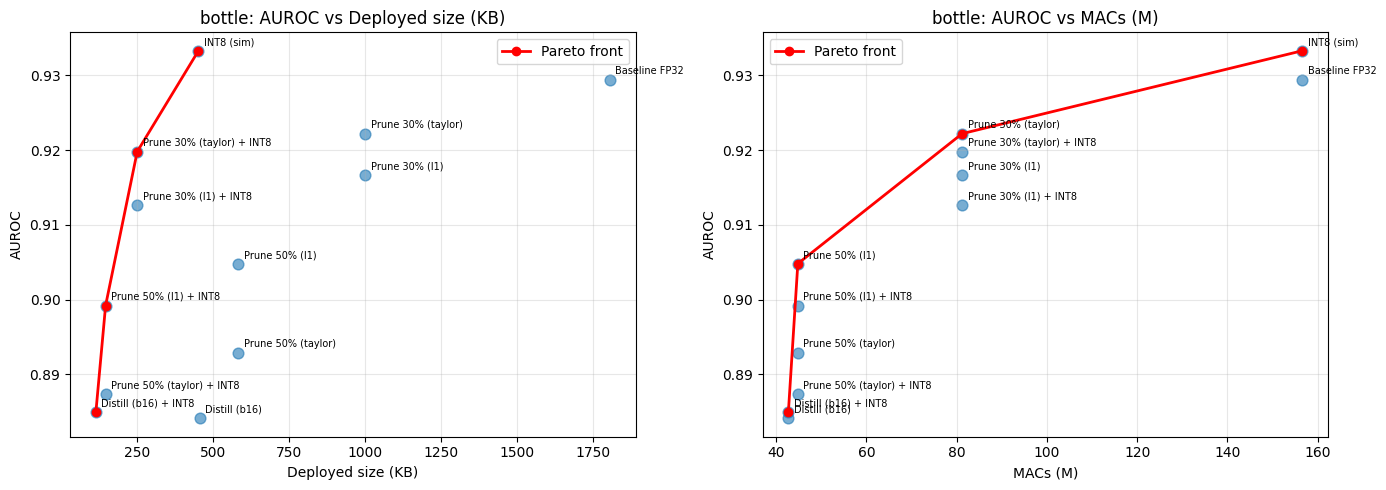

In [ ]:
def pareto_front(points):  # points: list of (x_cost, y_auroc, name); lower cost + higher auroc better
    pts = sorted(points, key=lambda p: p[0])
    front, best = [], -1
    for x, y, n in pts:
        if y > best: front.append((x, y, n)); best = y
    return front

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cost_key, label in [(axes[0], 'deployed_kb', 'Deployed size (KB)'),
                            (axes[1], 'macs_M', 'MACs (M)')]:
    pts = [(row[cost_key], row['auroc'], row['name']) for _, row in df.iterrows()]
    xs = [p[0] for p in pts]; ys = [p[1] for p in pts]
    ax.scatter(xs, ys, s=60, alpha=.6)
    for x, y, n in pts:
        ax.annotate(n, (x, y), fontsize=7, xytext=(4,4), textcoords='offset points')
    front = pareto_front(pts)
    ax.plot([p[0] for p in front], [p[1] for p in front], 'r-o', lw=2, label='Pareto front')
    ax.set_xlabel(label); ax.set_ylabel('AUROC'); ax.grid(alpha=.3); ax.legend()
    ax.set_title(f'{CATEGORY}: AUROC vs {label}')
plt.tight_layout()
plt.savefig(Path(CFG['out_dir']) / f'pareto_{CATEGORY}.png', dpi=120, bbox_inches='tight')
plt.show()

## 15. Loop over all categories (run after validating on bottle)
Uncomment to run the full sweep on all three categories and concatenate results.

In [19]:
import torch, shutil

# Make sure helper columns/structures exist
all_tables = {}
all_variants = {}

for CAT in ['bottle', 'hazelnut']:
    print(f'\n{"#"*60}\n#  {CAT.upper()}\n{"#"*60}')

    # 1. Run the sweep
    table, variants = run_sweep(CAT)

    # 2. Build the table with derived columns
    dfc = pd.DataFrame(table)
    dfc['macs_M'] = (dfc['macs'] / 1e6).round(1)
    dfc['auroc'] = dfc['auroc'].round(4)
    dfc['deployed_kb'] = dfc.apply(
        lambda r: r['n_params'] * (1 if ('int8' in r['technique'] or r['technique'] == 'quantization') else 4) / 1024,
        axis=1).round(1)
    dfc['category'] = CAT
    all_tables[CAT] = dfc
    all_variants[CAT] = variants

    # 3. Save table CSV
    dfc[['name','technique','auroc','n_params','macs_M','deployed_kb']] \
        .sort_values('auroc', ascending=False) \
        .to_csv(Path(CFG['out_dir']) / f'sweep_{CAT}.csv', index=False)

    # 4. Save model checkpoints (with conv_shapes for Stage 3 rebuild)
    for v in variants:
        safe_name = v['name'].replace(' ', '_').replace('%', 'pct').replace('+', 'plus').replace('(', '').replace(')', '')
        shapes = [(m.in_channels, m.out_channels)
                  for m in v['model'].modules()
                  if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d))]
        torch.save({
            'state_dict': v['model'].state_dict(),
            'name': v['name'], 'technique': v['technique'],
            'auroc': v['auroc'], 'n_params': v['n_params'], 'macs': v['macs'],
            'category': CAT, 'conv_shapes': shapes,
        }, Path(CFG['out_dir']) / f'model_{CAT}_{safe_name}.pt')

    # 5. Back up to Drive IMMEDIATELY after each category finishes
    shutil.copytree(CFG['out_dir'], '/content/drive/MyDrive/mvtec_stage2', dirs_exist_ok=True)
    print(f'✓ {CAT}: {len(variants)} checkpoints saved + backed up to Drive')

# 6. Combined CSV
combined = pd.concat(all_tables.values(), ignore_index=True)
combined.to_csv(Path(CFG['out_dir']) / 'sweep_all.csv', index=False)
shutil.copytree(CFG['out_dir'], '/content/drive/MyDrive/mvtec_stage2', dirs_exist_ok=True)

print('\n' + '='*50)
print('DONE. All checkpoints on disk:')
for f in sorted(Path(CFG['out_dir']).glob('model_*.pt')):
    print('  ', f.name)


############################################################
#  BOTTLE
############################################################

  COMPRESSION SWEEP: bottle
Baseline AUROC: 0.9651 | params 462,307
  [1/4] quantization...
  [2/4] pruning l1 30%...
    pruned: 462,307 -> 255,901 params (45% removed)
  [2/4] pruning l1 50%...
    pruned: 462,307 -> 149,251 params (68% removed)
  [2/4] pruning taylor 30%...
    pruned: 462,307 -> 255,901 params (45% removed)
  [2/4] pruning taylor 50%...
    pruned: 462,307 -> 149,251 params (68% removed)
  [3/4] distillation...
  [4/4] done.
✓ bottle: 12 checkpoints saved + backed up to Drive

############################################################
#  HAZELNUT
############################################################

  COMPRESSION SWEEP: hazelnut
Baseline AUROC: 0.8700 | params 462,307
  [1/4] quantization...
  [2/4] pruning l1 30%...
    pruned: 462,307 -> 255,901 params (45% removed)
  [2/4] pruning l1 50%...
    pruned: 462,307 -> 149,251

In [21]:
# Bottle results table
CAT = 'bottle'
dfh = all_tables[CAT][['name', 'technique', 'auroc', 'n_params', 'macs_M', 'deployed_kb']]
dfh = dfh.sort_values('auroc', ascending=False).reset_index(drop=True)
print(f'=== {CAT} ===')
print(dfh.to_string())

=== bottle ===
                         name            technique   auroc  n_params  macs_M  deployed_kb
0       Prune 30% (l1) + INT8      pruning_l1+int8  0.9667    255901    20.3        249.9
1               Baseline FP32                 none  0.9651    462307    39.2       1805.9
2              Prune 30% (l1)           pruning_l1  0.9651    255901    20.3        999.6
3                  INT8 (sim)         quantization  0.9643    462307    39.2        451.5
4          Prune 30% (taylor)       pruning_taylor  0.9619    255901    20.3        999.6
5   Prune 30% (taylor) + INT8  pruning_taylor+int8  0.9603    255901    20.3        249.9
6       Prune 50% (l1) + INT8      pruning_l1+int8  0.9556    149251    11.2        145.8
7              Prune 50% (l1)           pruning_l1  0.9556    149251    11.2        583.0
8          Prune 50% (taylor)       pruning_taylor  0.9429    149251    11.2        583.0
9   Prune 50% (taylor) + INT8  pruning_taylor+int8  0.9413    149251    11.2        1

In [24]:
# Hazelnut results table
CAT = 'hazelnut'
dfh = all_tables[CAT][['name', 'technique', 'auroc', 'n_params', 'macs_M', 'deployed_kb']]
dfh = dfh.sort_values('auroc', ascending=False).reset_index(drop=True)
print(f'=== {CAT} ===')
print(dfh.to_string())

=== hazelnut ===
                         name            technique   auroc  n_params  macs_M  deployed_kb
0       Prune 50% (l1) + INT8      pruning_l1+int8  0.8889    149251    11.2        145.8
1              Prune 50% (l1)           pruning_l1  0.8879    149251    11.2        583.0
2          Prune 50% (taylor)       pruning_taylor  0.8846    149251    11.2        583.0
3   Prune 50% (taylor) + INT8  pruning_taylor+int8  0.8846    149251    11.2        145.8
4   Prune 30% (taylor) + INT8  pruning_taylor+int8  0.8782    255901    20.3        249.9
5       Prune 30% (l1) + INT8      pruning_l1+int8  0.8746    255901    20.3        249.9
6                  INT8 (sim)         quantization  0.8739    462307    39.2        451.5
7          Prune 30% (taylor)       pruning_taylor  0.8711    255901    20.3        999.6
8              Prune 30% (l1)           pruning_l1  0.8707    255901    20.3        999.6
9               Baseline FP32                 none  0.8700    462307    39.2       

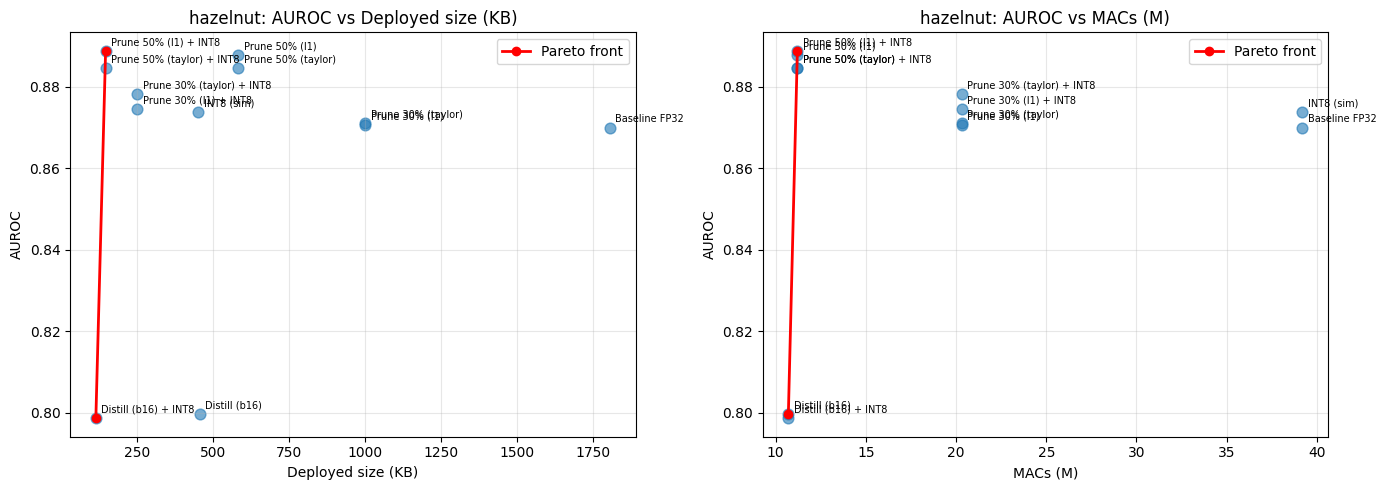

In [25]:
def pareto_front(points):
    pts = sorted(points, key=lambda p: p[0])
    front, best = [], -1
    for x, y, n in pts:
        if y > best: front.append((x, y, n)); best = y
    return front

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cost_key, label in [(axes[0], 'deployed_kb', 'Deployed size (KB)'),
                            (axes[1], 'macs_M', 'MACs (M)')]:
    pts = [(row[cost_key], row['auroc'], row['name']) for _, row in dfh.iterrows()]
    xs = [p[0] for p in pts]; ys = [p[1] for p in pts]
    ax.scatter(xs, ys, s=60, alpha=.6)
    for x, y, n in pts:
        ax.annotate(n, (x, y), fontsize=7, xytext=(4,4), textcoords='offset points')
    front = pareto_front(pts)
    ax.plot([p[0] for p in front], [p[1] for p in front], 'r-o', lw=2, label='Pareto front')
    ax.set_xlabel(label); ax.set_ylabel('AUROC'); ax.grid(alpha=.3); ax.legend()
    ax.set_title(f'{CAT}: AUROC vs {label}')
plt.tight_layout()
plt.savefig(Path(CFG['out_dir']) / f'pareto_{CAT}.png', dpi=120, bbox_inches='tight')
plt.show()

# Stage 2 — Report & Stage 3 Handoff

## What Stage 2 produces

For each category: a table of compressed variants with AUROC, parameter count, MACs, and theoretical INT8 size, plus the Pareto frontier (AUROC vs size / MACs). The Pareto-optimal variants are the candidates that move forward to on-device measurement.

## Important caveats

- **INT8 here is simulated** (weight-only fake-quantization) for an accuracy estimate. Real INT8 size, latency, and energy are measured in Stage 3 via TFLite Micro on the Arduino. Do not quote the Stage 2 INT8 KB as the final deployed size — it ignores activation quantization and runtime overhead.
- **Pruning ratios** are illustrative (30%, 50%). Sweep more finely if a particular ratio sits near an interesting accuracy cliff.
- **Same frozen protocol** (border 8, blur 5, mean) used for every variant. No per-variant tuning.

## Stage 3 — what to carry forward

1. Select the Pareto-optimal variants per category (typically: best-accuracy, smallest-that-stays-above-0.85, and one mid-point).
2. Export each selected PyTorch model to ONNX → TFLite (INT8) for TFLite Micro.
3. Deploy on the Arduino Nano 33 BLE Sense Rev 2; measure real latency, SRAM, flash, and energy/inference.
4. Replace the simulated INT8 size with the measured TFLite size, and add the hardware columns to the Pareto table.

## Open questions for Stage 3

- Which 3–4 variants per category actually get deployed? (Flash holds several; pick the ones spanning the Pareto front.)
- Does measured on-device latency track MACs linearly, or do memory effects dominate? (This decides whether MACs is a good proxy for energy.)
- For the Stage 4 adaptive policy: which variants form the "quality ladder" the runtime switches between?